In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import CubicSpline, interp1d
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]  = T[2]                                  # Left boundary (2 ghost points)
    T[-1] = T[-2]**2 / max(T[-3].item(), 1e-40)  # Right boundary


In [3]:
from scipy.interpolate import CubicSpline

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out, device):
    """
    Solve two-layer heat equation from t=0 to t=tf.

    Internally marches at the CFL-stable dt; outputs are resampled
    to n_t_out equally-spaced coarse times via cubic spline in time.

    Parameters
    ----------
    n_t_out : int
        Number of output time points (coarse grid), spanning (0, tf].
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz   # (nz+3,)

    m = torch.searchsorted(z, z_dis - 0.5*dz, right=True).item()
    print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')

    k_iL = 8*k1*k2 / (k1 + 7*k2)
    k_iR = 8*k1*k2 / (7*k1 + k2)
    kh = torch.where(z[:-1] < z_dis - 0.5*dz,
                     torch.tensor(k1, device=device),
                     torch.tensor(k2, device=device))   # (nz+2,)
    kh[m-1] = k_iL
    kh[m]   = k_iR

    # --- stability timestep for the whole interval [0, tf] ---
    dt_stab = 0.5 * (dz**2) / max(k1, k2)
    n_fine  = int(np.ceil(tf / dt_stab))
    dt      = tf / n_fine
    print(f'n_fine={n_fine}, dt={dt:.4e}, tf={tf}')

    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2] / 4)

    T  = torch.zeros(nz + 3, device=device)
    Jh = torch.zeros(nz + 2, device=device)

    # --- decide which fine steps to buffer for the spline ---
    stride = max(1, n_fine // (10 * n_t_out))
    buf_steps = list(range(stride - 1, n_fine, stride))
    if (n_fine - 1) not in buf_steps:
        buf_steps.append(n_fine - 1)

    buf_U = []
    buf_t = []

    for step in range(n_fine):
        set_BCs(T)
        Jh = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source

        if step in buf_steps:
            buf_U.append(T[1:-1].cpu().clone())
            buf_t.append((step + 1) * dt)

    set_BCs(T)
    T[m] = T[m] + (2*T[m] - T[m-1] - T[m+1]) / 6

    # --- cubic spline in time, evaluate at coarse output times ---
    t_fine_buf = np.array(buf_t)
    U_fine_buf = torch.stack(buf_U, dim=1).numpy()

    t_coarse = np.linspace(tf / n_t_out, tf, n_t_out)

    cs = CubicSpline(t_fine_buf, U_fine_buf, axis=1, bc_type='not-a-knot')
    U_coarse = torch.from_numpy(cs(t_coarse)).to(device)

    t_out = torch.tensor(t_coarse, device=device)
    return z[1:-1], t_out, U_coarse


In [4]:
def smooth_U(U, z, z_dis, k1, k2):
    """
    Smooths the kink at z_dis:
        z >= z_dis : U(z, t)                                (unchanged)
        z <  z_dis : U(z_dis, t) + alpha*(U(z,t) - U(z_dis, t))
    where alpha = k1/k2
    """
    alpha = k1 / k2
    m = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()

    U_smooth = U.clone()
    U_zd = U[m, :]                                         # (n_sub_t,)
    U_smooth[:m, :] = U_zd + alpha * (U[:m, :] - U_zd)

    return U_smooth


## Run the solver for Lz=8 and Lz=16

In [5]:
device = 'cuda'
%run func_defs.ipynb
k1 = 1.0; k2 = 2.0; z_dis = 1.0; Pda = 1.0; tf = 2.0

nz_unit = 10   # grid points per unit length (base resolution)
n_t_out = 8    # coarse output time points

# ── Lz = 8  (baseline domain) ────────────────────────────────────────────
Lz8 = 8.0
nz8 = int(Lz8) * nz_unit          # 80 points
print(f'--- Lz={Lz8}, nz={nz8} ---')
z8, t_out8, U8 = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz8, nz8, tf, n_t_out, device)
U8_smooth = smooth_U(U8, z8, z_dis, k1, k2)
print(f'U8 shape: {U8.shape}')

# ── Lz = 16  (doubled domain; doubled nz to keep same dz) ───────────────
Lz16 = 16.0
nz16 = int(Lz16) * nz_unit        # 160 points  (same dz = Lz/nz as Lz=8 run)
print(f'\n--- Lz={Lz16}, nz={nz16} ---')
z16, t_out16, U16 = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz16, nz16, tf, n_t_out, device)
U16_smooth = smooth_U(U16, z16, z_dis, k1, k2)
print(f'U16 shape: {U16.shape}')


--- Lz=8.0, nz=80 ---
Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
U8 shape: torch.Size([81, 8])

--- Lz=16.0, nz=160 ---
Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
U16 shape: torch.Size([161, 8])


## Restrict the Lz=16 solution to z ∈ [0, 8] for comparison

In [6]:
# Keep only the z16 nodes that lie within the Lz=8 domain
mask16    = z16 <= Lz8 + 1e-12          # boolean mask on the fine z-grid
z16_crop  = z16[mask16]                  # (n_crop,)
U16_crop  = U16[mask16, :]               # (n_crop, n_t_out) — raw
U16s_crop = U16_smooth[mask16, :]        # (n_crop, n_t_out) — smoothed

# Interpolate the cropped Lz=16 solution onto the z8 grid for
# pixel-to-pixel comparison (the grids are identical when dz matches,
# but the interp makes it robust to any nz_unit choice).
z8_np   = z8.cpu().numpy()
z16c_np = z16_crop.cpu().numpy()

U16s_on_z8 = torch.zeros_like(U8_smooth)
for i in range(n_t_out):
    f = interp1d(z16c_np, U16s_crop[:, i].cpu().numpy(),
                 kind='cubic', fill_value='extrapolate')
    U16s_on_z8[:, i] = torch.from_numpy(f(z8_np)).to(device)

print(f'z16_crop shape  : {z16_crop.shape}')
print(f'U16s_on_z8 shape: {U16s_on_z8.shape}  (matches U8_smooth)')


z16_crop shape  : torch.Size([81])
U16s_on_z8 shape: torch.Size([81, 8])  (matches U8_smooth)


## Plots

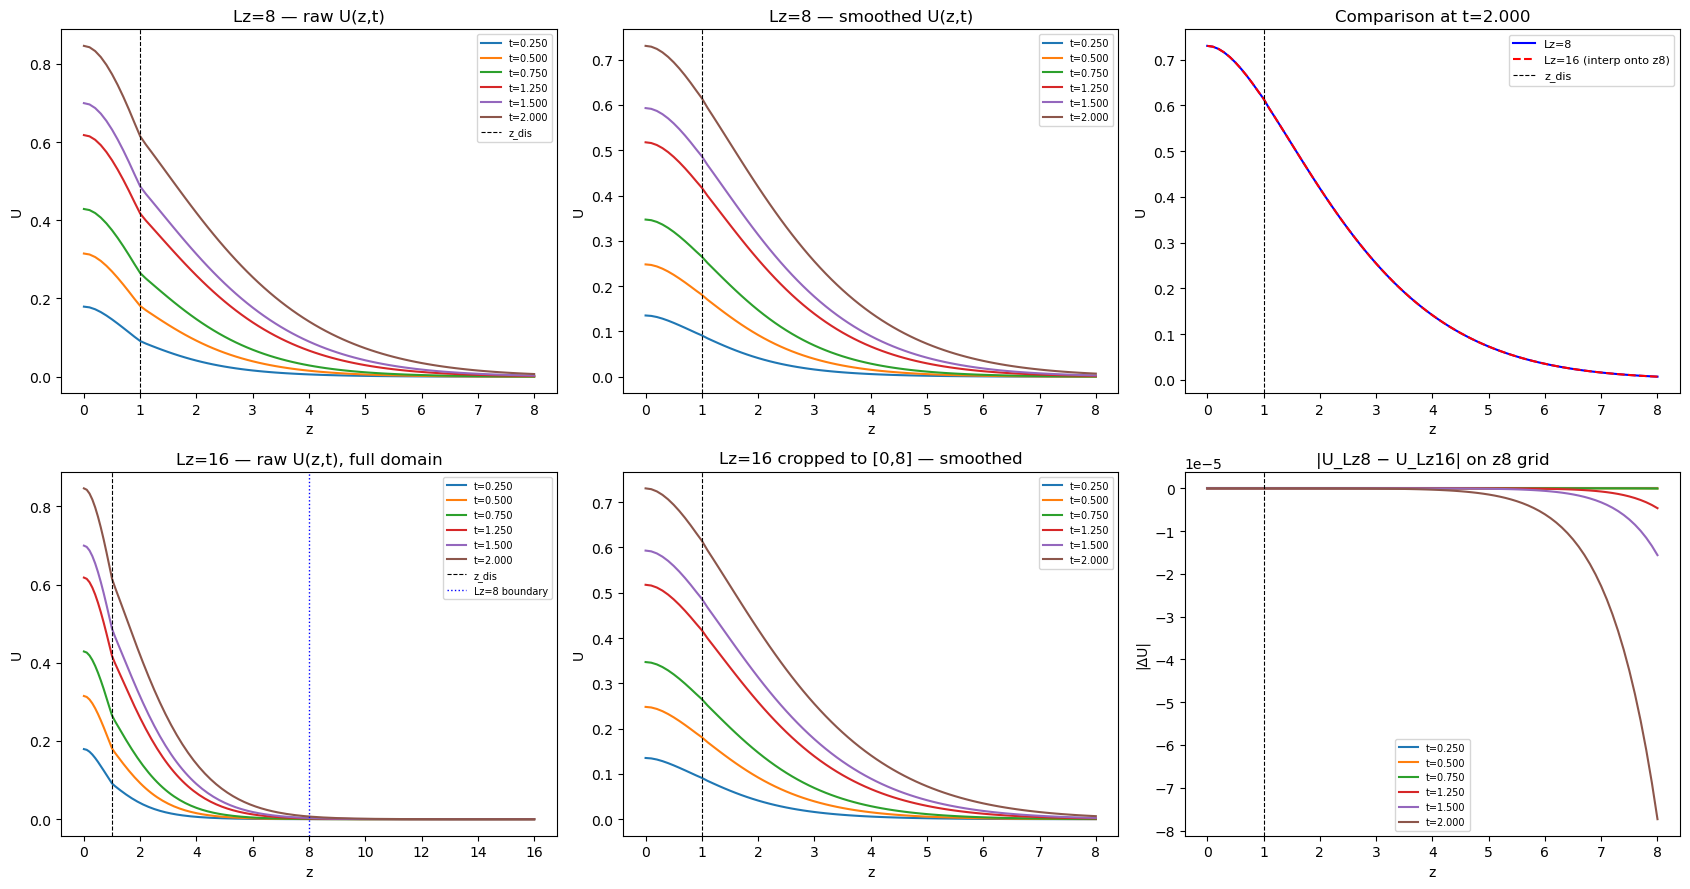

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

z8_cpu  = z8.cpu();  t_cpu = t_out8.cpu()
z16_cpu = z16.cpu(); z16c_cpu = z16_crop.cpu()
U8_cpu  = U8.cpu();  U8s_cpu  = U8_smooth.cpu()
U16_cpu = U16.cpu(); U16s_cpu = U16_smooth.cpu()
U16s_on_z8_cpu = U16s_on_z8.cpu()
mask16_cpu = mask16.cpu()

idx = torch.linspace(0, n_t_out - 1, min(6, n_t_out)).long()

# ── Row 0, col 0: Lz=8 raw ───────────────────────────────────────────────
ax = axes[0, 0]
for i in idx:
    ax.plot(z8_cpu, U8_cpu[:, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
ax.set(xlabel='z', ylabel='U', title='Lz=8 — raw U(z,t)')
ax.legend(fontsize=7)

# ── Row 0, col 1: Lz=8 smoothed ──────────────────────────────────────────
ax = axes[0, 1]
for i in idx:
    ax.plot(z8_cpu, U8s_cpu[:, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', lw=0.8)
ax.set(xlabel='z', ylabel='U', title='Lz=8 — smoothed U(z,t)')
ax.legend(fontsize=7)

# ── Row 1, col 0: Lz=16 full domain ──────────────────────────────────────
ax = axes[1, 0]
for i in idx:
    ax.plot(z16_cpu, U16_cpu[:, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
ax.axvline(Lz8,   color='b', linestyle=':',  lw=1.0, label='Lz=8 boundary')
ax.set(xlabel='z', ylabel='U', title='Lz=16 — raw U(z,t), full domain')
ax.legend(fontsize=7)

# ── Row 1, col 1: Lz=16 cropped + smoothed ───────────────────────────────
ax = axes[1, 1]
for i in idx:
    ax.plot(z16c_cpu, U16s_cpu[mask16_cpu, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', lw=0.8)
ax.set(xlabel='z', ylabel='U', title='Lz=16 cropped to [0,8] — smoothed')
ax.legend(fontsize=7)

# ── Row 0, col 2: direct comparison (last snapshot) ──────────────────────
ax = axes[0, 2]
i_last = n_t_out - 1
ax.plot(z8_cpu, U8s_cpu[:, i_last],        'b-',  label='Lz=8')
ax.plot(z8_cpu, U16s_on_z8_cpu[:, i_last], 'r--', label='Lz=16 (interp onto z8)')
ax.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
ax.set(xlabel='z', ylabel='U', title=f'Comparison at t={t_cpu[i_last]:.3f}')
ax.legend(fontsize=8)

# ── Row 1, col 2: absolute difference ────────────────────────────────────
ax = axes[1, 2]
diff = (U16s_on_z8_cpu- U8s_cpu)
for i in idx:
    ax.plot(z8_cpu, diff[:, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', lw=0.8)
ax.set(xlabel='z', ylabel='|ΔU|', title='|U_Lz8 − U_Lz16| on z8 grid')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


## Convert to (s, τ) coordinates and save

In [ ]:
def prep_and_save(z, t_out, U_smooth, k1, k2, z_dis, nz, device, out_file):
    zt_grid = torch.cartesian_prod(z, t_out)
    zz = zt_grid[:, 0]; tt = zt_grid[:, 1]
    stau = torch.column_stack(z_t_to_s_tau(zz, tt))
    W = U_smooth / t_out
    W = W.reshape(-1, 1)
    kratio = torch.ones(len(stau[:, 1]), device=device) * (k1 / k2)
    z_disv = torch.ones(len(stau[:, 1]), device=device) * z_dis
    data_to_save = {
        't': tt, 'z': zz,
        'kratio': kratio, 'zdis': z_disv,
        'stau': stau, 'W': W,
    }
    torch.save(data_to_save, out_file)
    print(f'Saved -> {out_file}  |  W shape: {W.shape}')

prep_and_save(z8,  t_out8,  U8_smooth,  k1, k2, z_dis, nz8,  device,
              f'./data/2layer_k1{k1}_k2{k2}_Lz{int(Lz8)}_nz{nz8}.pt')

prep_and_save(z16, t_out16, U16_smooth, k1, k2, z_dis, nz16, device,
              f'./data/2layer_k1{k1}_k2{k2}_Lz{int(Lz16)}_nz{nz16}.pt')
